## Data import

In [1]:
import pandas as pd

In [2]:
raw_df = pd.read_csv("../datsets/raw_dataset/Telco-Customer-Churn.csv")
df = raw_df.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [4]:
y = df["Churn"].map({"Yes": 1, "No": 0})

In [5]:
df.drop(["customerID", "Churn"], axis=1, inplace=True)

In [6]:
X = df

## Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [8]:
X_train,X_val,y_train,y_val = train_test_split(
    X_temp,y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

In [9]:
X_train.shape

(4507, 19)

In [10]:
X_train.sample(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3745,Male,0,No,No,7,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.25,669.0
6566,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.55,8152.3


## Implementing Preprocessing pipeline

In [11]:
numeric_features = ["tenure", "MonthlyCharges", "TotalChargees"]
binary_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",  "PaperlessBilling",]
categorical_features = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]



In [12]:
for col in binary_features:
    print(col, X_train[col].unique())

gender ['Male' 'Female']
SeniorCitizen [0 1]
Partner ['No' 'Yes']
Dependents ['No' 'Yes']
PhoneService ['Yes' 'No']
PaperlessBilling ['No' 'Yes']


In [21]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
binary_features = ["gender", "Partner", "Dependents", "PhoneService",  "PaperlessBilling",]
categorical_features = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler

In [32]:
def binary_encoder(X):
    X = X.copy()

    mappings = {
        "gender" : {"Male":1, "Female":0},
        "Partner" : {"Yes" : 1, "No": 0},
        "Dependents" : {"Yes" : 1, "No": 0},
        "PhoneService" : {"Yes" : 1, "No": 0},
        "PaperlessBilling" : {"Yes" : 1, "No": 0}
    }

    for col, mapping in mappings.items():
        X[col] = X[col].map(mapping)

    return X

In [33]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("Scaler", StandardScaler())
])

In [34]:
binary_pipeline = Pipeline([
    ("encoder", FunctionTransformer(binary_encoder))
])

In [35]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(4507, 40)
(1409, 40)


In [39]:
ohe = preprocessor.named_transformers_["cat"] \
                  .named_steps["ohe"]

ohe_feature_names = ohe.get_feature_names_out(categorical_features)

print(ohe_feature_names)

['MultipleLines_No' 'MultipleLines_No phone service' 'MultipleLines_Yes'
 'InternetService_DSL' 'InternetService_Fiber optic' 'InternetService_No'
 'OnlineSecurity_No' 'OnlineSecurity_No internet service'
 'OnlineSecurity_Yes' 'OnlineBackup_No' 'OnlineBackup_No internet service'
 'OnlineBackup_Yes' 'DeviceProtection_No'
 'DeviceProtection_No internet service' 'DeviceProtection_Yes'
 'TechSupport_No' 'TechSupport_No internet service' 'TechSupport_Yes'
 'StreamingTV_No' 'StreamingTV_No internet service' 'StreamingTV_Yes'
 'StreamingMovies_No' 'StreamingMovies_No internet service'
 'StreamingMovies_Yes' 'Contract_Month-to-month' 'Contract_One year'
 'Contract_Two year' 'PaymentMethod_Bank transfer (automatic)'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']


In [40]:
X_val_processed = preprocessor.transform(X_val)

## Model training
### Dummy Classifier

In [41]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_processed, y_train)

y_pred_dummy = dummy.predict(X_val_processed)

In [42]:
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
) 

In [43]:
print(classification_report(y_val, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85       828
           1       0.00      0.00      0.00       299

    accuracy                           0.73      1127
   macro avg       0.37      0.50      0.42      1127
weighted avg       0.54      0.73      0.62      1127



d:\Anaconda3\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda3\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda3\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [46]:
print("Accuracy:", accuracy_score(y_val, y_pred_dummy))
print("Precision:", precision_score(y_val, y_pred_dummy, average="weighted"))
print("ROC-AUC:", roc_auc_score(y_val, dummy.predict_proba(X_val_processed)[:, 1]))

Accuracy: 0.7346938775510204
Precision: 0.5397750937109538
ROC-AUC: 0.5


d:\Anaconda3\envs\torchgpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [48]:
import matplotlib.pyplot as plt

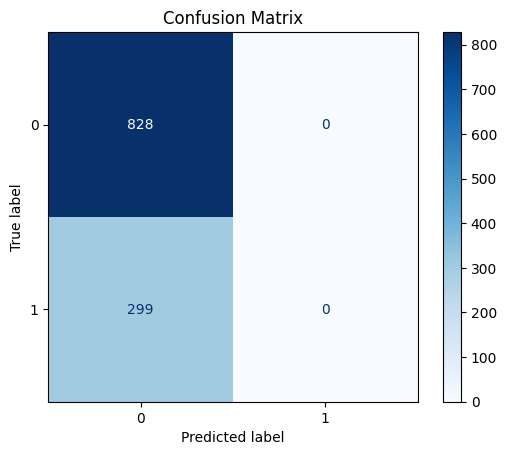

In [49]:
cm = confusion_matrix(y_val, y_pred_dummy)
ConfusionMatrixDisplay(cm, display_labels=dummy.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [50]:
print("F1:", f1_score(y_val, y_pred_dummy, average="weighted"))

F1: 0.622328931572629


In [51]:
print("F1:", f1_score(y_val, y_pred_dummy))

F1: 0.0


### Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)

In [53]:
lr.fit(X_train_processed, y_train)

y_pred_lr = lr.predict(X_val_processed)

In [56]:
print(classification_report(y_val, y_pred_lr))
print("Precison:", precision_score(y_val, y_pred_lr, average="weighted"))
print("F1", f1_score(y_val, y_pred_lr, average="weighted"))
print("ROX-AUC", roc_auc_score(y_val, lr.predict_proba(X_val_processed)[:,1]))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       828
           1       0.70      0.55      0.61       299

    accuracy                           0.82      1127
   macro avg       0.77      0.73      0.75      1127
weighted avg       0.81      0.82      0.81      1127

Precison: 0.807610464865304
F1 0.8085954864932324
ROX-AUC 0.8481330683599114


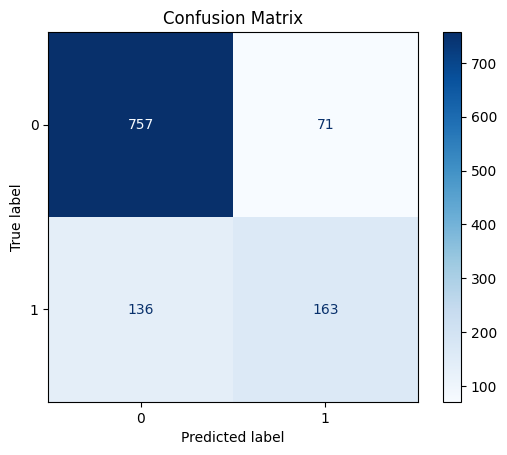

In [57]:
cm = confusion_matrix(y_val, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=lr.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

we still have a huge amount of false negatives, approximately equal to true positives

The Logistic Regression model significantly outperformed the Dummy Classifier. It achieved a ROC-AUC score of 0.848, indicating strong class separation ability. The model correctly identified 163 out of 299 churned customers, resulting in a recall of 54.5% for the churn class. However, 136 churned customers were still misclassified as non-churners, suggesting room for improvement in identifying customers at risk of leaving.